### Bell State is <strong>maximally entangled</strong> state of two qubits that can't be represented by combination of two individual qubits

In [1]:
!pip install -q qiskit-aer

Imports

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

Preparing execution backend

In [4]:
# For non-GPU accelerated backend
backend = AerSimulator(device='CPU')
# For GPU accelerated backend
# backend = AerSimulator(device='GPU')

Preparing circuit

In [5]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0,1)
qc.measure(0, 0)
qc.measure(1, 1)
# Visualise the circuit
qc.draw()

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

Transpile

In [6]:
tqc = transpile(qc, backend)

Execution

In [7]:
job = backend.run(tqc, shots=10240)

Measurement Counts: {'11': 5152, '00': 5088}


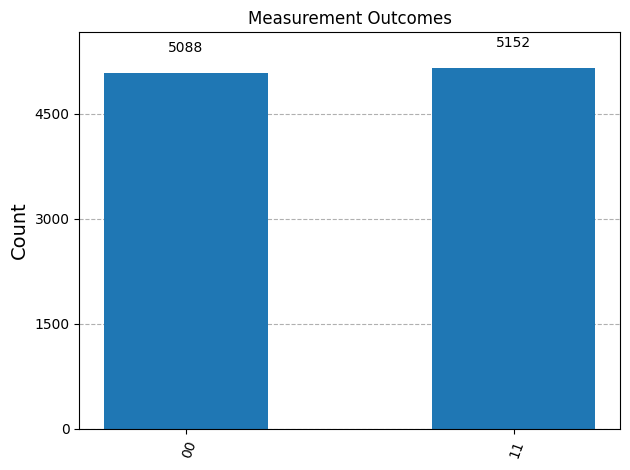

In [8]:
# 4. Get the Results
result = job.result()
counts = result.get_counts(tqc) # Get counts dictionary

# 5. Print the Counts (shows outcomes like {'0': 500, '1': 524})
print("Measurement Counts:", counts)

# 6. Visualize the Results (optional, but recommended)
plot_histogram(counts, title='Measurement Outcomes')